# 1 - GARGAMOS IMAGENES PARA EL DATASET

## IMPORTAMOS LIBRERIAS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
BASE_DIR = '/content/drive/MyDrive/CODIGOG6/MODULO6/4-REDES-NEURONALES-CONVOLUCIONALES/datasets'

In [3]:
import os
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VALIDATION_DIR = os.path.join(BASE_DIR, 'validation')
TEST_DIR = os.path.join(BASE_DIR, 'test')
print(TRAIN_DIR)
print(VALIDATION_DIR)
print(TEST_DIR)

/content/drive/MyDrive/CODIGOG6/MODULO6/4-REDES-NEURONALES-CONVOLUCIONALES/datasets/train
/content/drive/MyDrive/CODIGOG6/MODULO6/4-REDES-NEURONALES-CONVOLUCIONALES/datasets/validation
/content/drive/MyDrive/CODIGOG6/MODULO6/4-REDES-NEURONALES-CONVOLUCIONALES/datasets/test


In [4]:
train_gatos_dir = os.path.join(TRAIN_DIR, 'gatos')
train_perros_dir = os.path.join(TRAIN_DIR, 'perros')

validation_gatos_dir = os.path.join(VALIDATION_DIR, 'gatos')
validation_perros_dir = os.path.join(VALIDATION_DIR, 'perros')

test_gatos_dir = os.path.join(TEST_DIR, 'gatos')
test_perros_dir = os.path.join(TEST_DIR, 'perros')

print(train_gatos_dir)
print(train_perros_dir)
print(validation_gatos_dir)
print(validation_perros_dir)
print(test_gatos_dir)
print(test_perros_dir)

/content/drive/MyDrive/CODIGOG6/MODULO6/4-REDES-NEURONALES-CONVOLUCIONALES/datasets/train/gatos
/content/drive/MyDrive/CODIGOG6/MODULO6/4-REDES-NEURONALES-CONVOLUCIONALES/datasets/train/perros
/content/drive/MyDrive/CODIGOG6/MODULO6/4-REDES-NEURONALES-CONVOLUCIONALES/datasets/validation/gatos
/content/drive/MyDrive/CODIGOG6/MODULO6/4-REDES-NEURONALES-CONVOLUCIONALES/datasets/validation/perros
/content/drive/MyDrive/CODIGOG6/MODULO6/4-REDES-NEURONALES-CONVOLUCIONALES/datasets/test/gatos
/content/drive/MyDrive/CODIGOG6/MODULO6/4-REDES-NEURONALES-CONVOLUCIONALES/datasets/test/perros


# 2 - EJEMPLO DE DATA AUGMENTATION

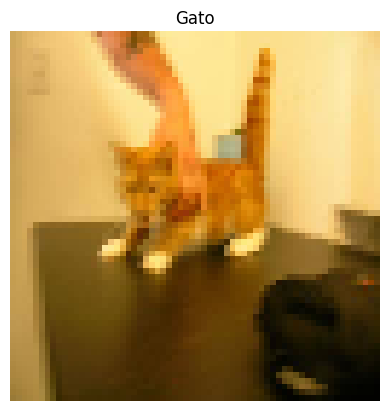

In [5]:
from tensorflow.keras.preprocessing import image
img = image.load_img(f'{train_gatos_dir}/cat.0.jpg',target_size=(64,64))
plt.imshow(img)
plt.title('Gato')
plt.axis('off')
plt.show()

# CREAMOS UN OBJETO QUE APLIQUE DATA AUGMENTATION

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
augmented_data = ImageDataGenerator(
    rescale=1. /255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

## Parámetros de Augmentación de Imágenes

### `rescale=1./255`
Normaliza los valores de los píxeles dividiéndolos entre 255.  

Las imágenes suelen tener valores en el rango `[0, 255]`, y este parámetro los convierte a un rango `[0, 1]`, lo cual es beneficioso para entrenar redes neuronales.  

### `rotation_range=40`
Rota la imagen aleatoriamente hasta 40 grados en ambas direcciones (sentido horario y antihorario).  

Introduce variabilidad en la orientación de los datos de entrenamiento.  

### `width_shift_range=0.2`
Desplaza la imagen horizontalmente hasta un 20% del ancho de la imagen de forma aleatoria.  

Simula variaciones en la posición de los objetos dentro de la imagen.  

### `height_shift_range=0.2`
Desplaza la imagen verticalmente hasta un 20% de la altura de la imagen de forma aleatoria.  

Similar a `width_shift_range`, pero en la dirección vertical.  

### `shear_range=0.2`
Aplica una transformación de cizallamiento (*shear*), que distorsiona la imagen como si se estuviera viendo desde un ángulo inclinado.  

Introduce variabilidad en la perspectiva.  

### `zoom_range=0.2`
Aplica un zoom aleatorio dentro del rango especificado (20% en este caso).  

Simula variaciones en la distancia del objeto respecto a la cámara.  

### `horizontal_flip=True`
Realiza un espejado horizontal aleatorio (voltea la imagen de izquierda a derecha).  

Útil para imágenes donde la orientación izquierda-derecha no es crucial (por ejemplo, fotos de animales o paisajes).  

# APLICAMOS NUESTRO OBJETO PARA GENERAR IMAGENES ALEATORIAS DE LA IMAGEN DE MUESTRA

In [7]:
from tensorflow.keras.preprocessing import image
img = image.load_img(f'{train_gatos_dir}/cat.0.jpg',target_size=(64,64))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

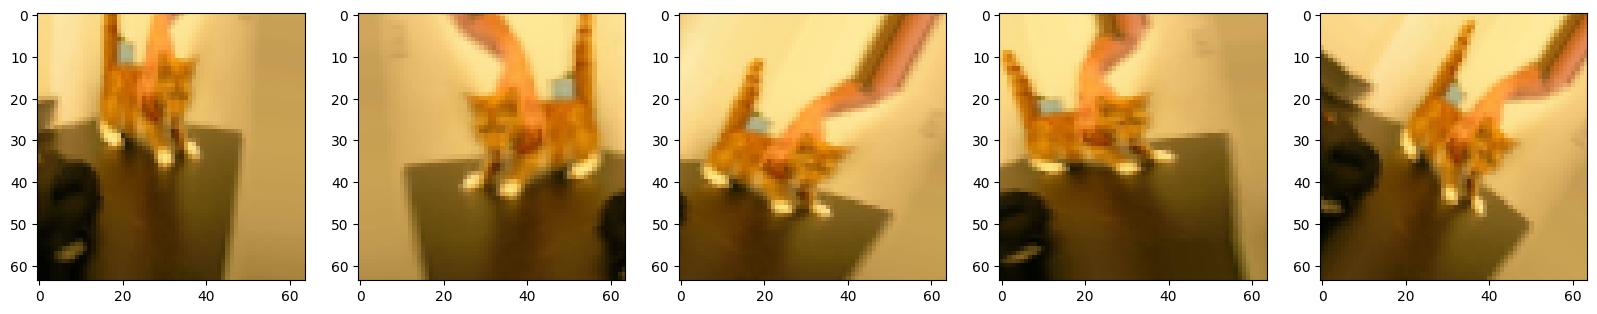

In [8]:
# Generar las imágenes aumentadas
i = 0
fig, ax = plt.subplots(1, 5, figsize=(20, 20))  # Mostrar 5 imágenes aumentadas
for batch in augmented_data.flow(img_array, batch_size=1):
    ax[i].imshow(image.array_to_img(batch[0]))  # Convertir el array a imagen y mostrarla
    i += 1
    if i % 5 == 0:
        break  # Solo mostrar 5 imágenes
plt.show()